# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [125]:
# Load the libraries as required.
import numpy as np
import pandas as pd
import shap
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import pickle

In [126]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]

fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()
fires_dt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


# Get X and Y

Create the features data frame and target data.

In [127]:
# Define the feature set (excluding 'area' which is the target variable)
X = fires_dt.drop(columns=['area'])

In [128]:
# Define the target variable
y = fires_dt['area']

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [129]:
# Define numerical and categorical columns
num_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
cat_features = ['month', 'day']

# Define transformations
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Create ColumnTransformer for preproc1
preproc1 = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Display the transformer
preproc1

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

### Preproc 2

Create preproc2 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [130]:
# Choose a non-linear transformation
num_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method='yeo-johnson'))
])

# One-hot encode categorical features
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Create ColumnTransformer for preproc2
preproc2 = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Display the transformer
preproc2

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('power',
                                                  PowerTransformer())]),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [131]:
# Pipeline A = preproc1 + baseline

# Create the pipeline: preprocessor + linear regression
pipeline_A = Pipeline(steps=[
    ('preprocessing', preproc1),
    ('regressor', LinearRegression())
])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluate the pipeline using cross-validation (e.g., RMSE)
cv_scores = cross_val_score(pipeline_A, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

# Print cross-validation results
print(f"Cross-validation RMSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit the model on the entire training set and evaluate on the test set
pipeline_A.fit(X_train, y_train)
test_score = pipeline_A.score(X_test, y_test)
print(f"Test R-squared: {test_score:.4f}")

Cross-validation RMSE: 41.1774 (+/- 23.1333)
Test R-squared: 0.0148


In [132]:
# Pipeline B = preproc2 + baseline

# Create the pipeline: preprocessor + linear regression
pipeline_B = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', LinearRegression())
])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluate the pipeline using cross-validation (e.g., RMSE)
cv_scores = cross_val_score(pipeline_B, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

# Print cross-validation results
print(f"Cross-validation RMSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit the model on the entire training set and evaluate on the test set
pipeline_B.fit(X_train, y_train)
test_score = pipeline_B.score(X_test, y_test)
print(f"Test R-squared: {test_score:.4f}")

Cross-validation RMSE: 40.2264 (+/- 23.3213)
Test R-squared: 0.0230


In [133]:
# Pipeline C = preproc1 + advanced model

# Create the pipeline: preprocessor1 + Gradient Boosting
pipeline_C = Pipeline(steps=[
    ('preprocessing', preproc1),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluate the pipeline using cross-validation (e.g., RMSE)
cv_scores = cross_val_score(pipeline_C, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

# Print cross-validation results
print(f"Cross-validation RMSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit the model on the entire training set and evaluate on the test set
pipeline_C.fit(X_train, y_train)
test_score = pipeline_C.score(X_test, y_test)
print(f"Test R-squared: {test_score:.4f}")

Cross-validation RMSE: 63.5951 (+/- 21.5122)
Test R-squared: -0.0067


In [134]:
# Pipeline D = preproc2 + advanced model

# Create the pipeline: preprocessor1 + Gradient Boosting
pipeline_D = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluate the pipeline using cross-validation (e.g., RMSE)
cv_scores = cross_val_score(pipeline_D, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

# Print cross-validation results
print(f"Cross-validation RMSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit the model on the entire training set and evaluate on the test set
pipeline_D.fit(X_train, y_train)
test_score = pipeline_D.score(X_test, y_test)
print(f"Test R-squared: {test_score:.4f}")

Cross-validation RMSE: 64.3239 (+/- 20.2350)
Test R-squared: 0.0038


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [ ]:
# Define parameter grid
param_grid_A = {
    'regressor__fit_intercept': [True, False],
    'regressor__copy_X': [True, False],
    'regressor__n_jobs': [1, 2, 3, -1],
}

# Perform GridSearch
grid_search_A = GridSearchCV(pipeline_A, param_grid_A, cv=5, scoring='neg_root_mean_squared_error')

# Fit GridSearch
grid_search_A.fit(X_train, y_train)

# Print the best hyperparameter
print(f"Best hyperparameter for Pipeline A: {grid_search_A.best_params_}")

# Print the best cross-validation score (RMSE)
print(f"Best CV RMSE for Pipeline A: {-grid_search_A.best_score_:.4f}")

# Evaluate the final model on the test set
test_score_A = grid_search_A.score(X_test, y_test)
print(f"Test R-squared for Pipeline A: {test_score_A:.4f}")

Best hyperparameter for Pipeline A: {'regressor__copy_X': True, 'regressor__fit_intercept': False, 'regressor__n_jobs': 1}
Best CV RMSE for Pipeline A: 41.1730
Test R-squared for Pipeline A: -107.7668


In [ ]:
# Define parameter grid
param_grid_A = {
    'regressor__fit_intercept': [True, False],
    'regressor__copy_X': [True, False],
    'regressor__n_jobs': [1, 2, 3, -1],
}

# Perform GridSearch
grid_search_B = GridSearchCV(pipeline_B, param_grid_B, cv=5, scoring='neg_root_mean_squared_error')

# Fit GridSearch
grid_search_B.fit(X_train, y_train)

# Print the best hyperparameter
print(f"Best hyperparameter for Pipeline B: {grid_search_B.best_params_}")

# Print the best cross-validation score (RMSE)
print(f"Best CV RMSE for Pipeline B: {-grid_search_B.best_score_:.4f}")

# Evaluate the final model on the test set
test_score_B = grid_search_B.score(X_test, y_test)
print(f"Test R-squared for Pipeline B: {test_score_B:.4f}")

Best hyperparameter for Pipeline B: {'regressor__fit_intercept': False}
Best CV RMSE for Pipeline B: 40.2248
Test R-squared for Pipeline B: -107.3159


In [137]:
# Define parameter grid
param_grid_C = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__learning_rate': [0.01, 0.1, 0.2]
}

# Perform GridSearch
grid_search_C = GridSearchCV(pipeline_C, param_grid_C, cv=5, scoring='neg_root_mean_squared_error')

# Fit GridSearch
grid_search_C.fit(X_train, y_train)

# Print the best hyperparameters
print(f"Best hyperparameters for Pipeline C: {grid_search_C.best_params_}")

# Print the best cross-validation score (RMSE)
print(f"Best CV RMSE for Pipeline C: {-grid_search_C.best_score_:.4f}")

# Evaluate the final model on the test set
test_score_C = grid_search_C.score(X_test, y_test)
print(f"Test R-squared for Pipeline C: {test_score_C:.4f}")

Best hyperparameters for Pipeline C: {'regressor__learning_rate': 0.01, 'regressor__n_estimators': 50}
Best CV RMSE for Pipeline C: 45.7217
Test R-squared for Pipeline C: -109.1449


In [138]:
# Define parameter grid
param_grid_D = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__learning_rate': [0.01, 0.1, 0.2]
}

# Perform GridSearch for each pipeline
grid_search_D = GridSearchCV(pipeline_D, param_grid_D, cv=5, scoring='neg_root_mean_squared_error')

# Fit GridSearch for each pipeline
grid_search_D.fit(X_train, y_train)

# Print the best hyperparameters
print(f"Best hyperparameters for Pipeline D: {grid_search_D.best_params_}")

# Print the best cross-validation score (RMSE)
print(f"Best CV RMSE for Pipeline D: {-grid_search_D.best_score_:.4f}")

# Evaluate the final model on the test set
test_score_D = grid_search_D.score(X_test, y_test)
print(f"Test R-squared for Pipeline D: {test_score_D:.4f}")

Best hyperparameters for Pipeline D: {'regressor__learning_rate': 0.01, 'regressor__n_estimators': 50}
Best CV RMSE for Pipeline D: 45.8567
Test R-squared for Pipeline D: -109.1467


# Evaluate

+ Which model has the best performance?

Pipeline B has the lowest RMSE, so Pipeline B has the best performance

# Export

+ Save the best performing model to a pickle file.

In [139]:
# Assuming the best model is from Pipeline B
best_model_B = grid_search_B.best_estimator_

# Save the model to a pickle file
with open('best_model_B.pkl', 'wb') as f:
    pickle.dump(best_model_B, f)

print("Best model from Pipeline B saved successfully.")

Best model from Pipeline B saved successfully.


In [140]:
# Load the model from the pickle file
with open('best_model_B.pkl', 'rb') as f:
    loaded_model_B = pickle.load(f)

print("Model loaded successfully.")

Model loaded successfully.


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

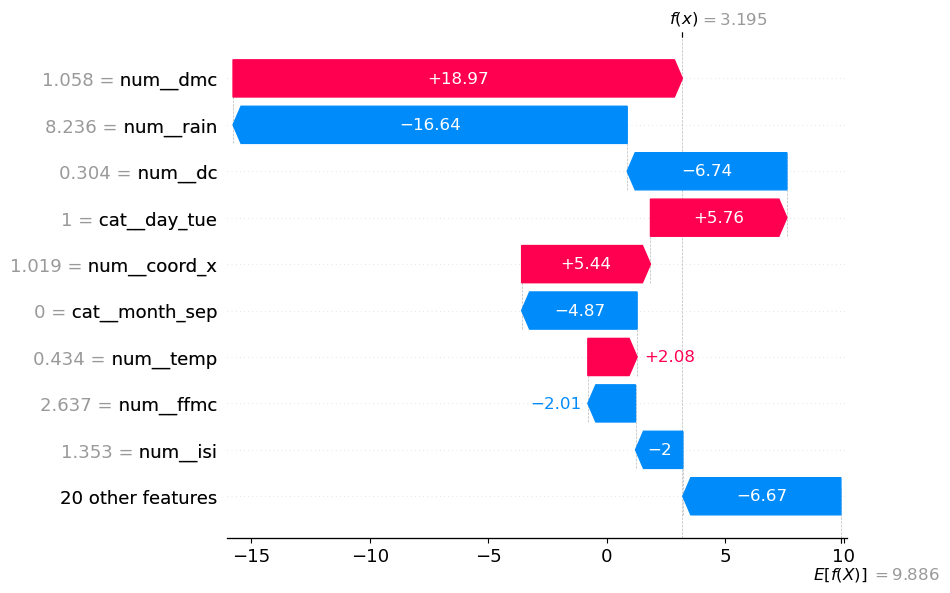

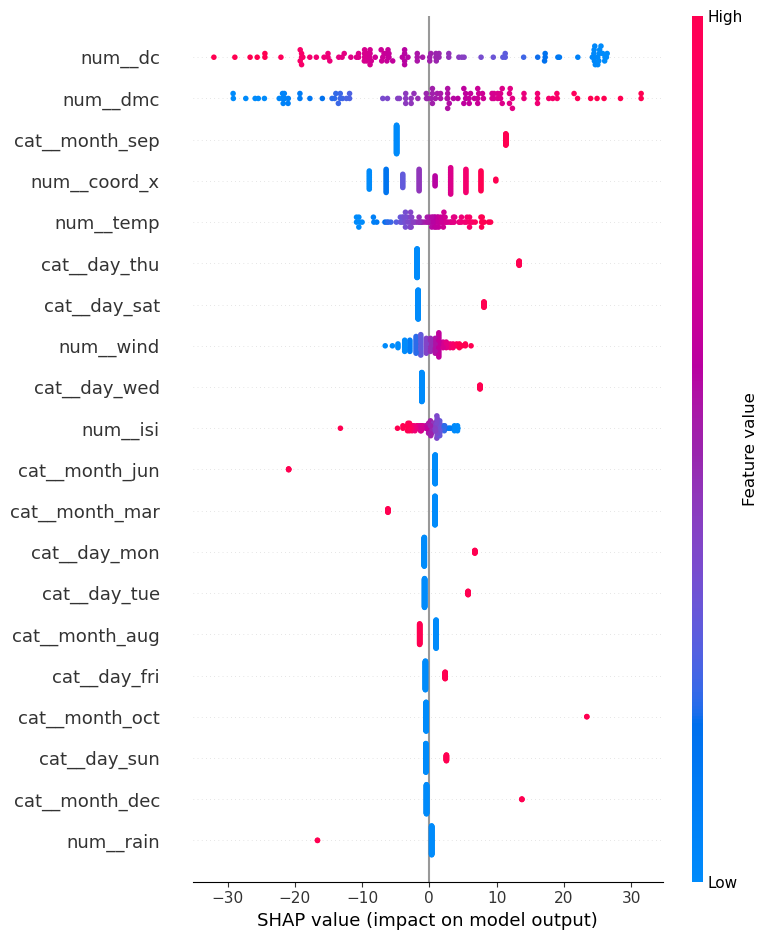

In [141]:
# Extract preprocessor and classifier from pipeline
preprocessor = loaded_model_B.named_steps['preprocessing']
regressor = loaded_model_B.named_steps['regressor']

# Transform test data using the preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Ensure feature names are retained
feature_names = preprocessor.get_feature_names_out()

# Initialize SHAP explainer
explainer = shap.explainers.Linear(regressor, X_test_transformed, feature_names=feature_names)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

# Selecting the observation at index 1
shap.plots.waterfall(shap_values[1])

# Plot SHAP summary
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

1. The most important features that explain the prediction for the observation at index 1 are num_dmc, num_rain, and num_dc.

2. Across the training set the most important features are num_dc, num_dmc, cat_month_sep, because these features show a wide range of SHAP values, indicating strong influence. The least important features are cat_day_sun, cat_month_dec, and num_rain.

3. I would remove cat_day_sun, cat_month_dec, and num_rain, because these features have SHAP valures close to zero, indicating minimal predictive value. I would test if the features were actually enhancing model performance by retaining the model without these features and comparing key metrics like RMSE, accuracy, etc.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.